# LC Resonant Converter — Full Analysis
| Signal | File | Description |
|---|---|---|
| **CH1** | `FET_CH1.csv` | High-side FET gate |
| **CH2** | `FET_CH2.csv` | Low-side FET gate |
| **TP4** | `coil_waveform.csv` | Switch node / PCB coil voltage |

| Parameter | Value |
|---|---|
| Gate sample rate | 1 GS/s (1 ns) · span ±70 µs |
| TP4 sample rate | 2 GS/s (0.5 ns) · span ±35 µs |
| Designed f_resonant | ~104 kHz |
| Gate driver | UCC27714DR |

## 1. Imports & style

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.signal import find_peaks

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

C1  = '#185FA5'   # CH1 high-side (blue)
C2  = '#0F6E56'   # CH2 low-side  (teal)
CTP = '#C97B2F'   # TP4 coil      (amber)
CDEAD = 'orange'
CST   = 'red'

## 2. Load all channels

In [2]:
def load_csv(path, start_s, inc_s):
    seqs, volts = [], []
    with open(path, newline='') as f:
        for row in csv.reader(f):
            if len(row) < 2: continue
            try:
                seqs.append(int(row[0]))
                volts.append(float(row[1]))
            except ValueError:
                pass
    seq   = np.array(seqs)
    volts = np.array(volts)
    time  = (start_s + seq * inc_s) * 1e6   # µs
    return time, volts

# Gate signals — 1 GS/s
t1, v1 = load_csv('FET_CH1.csv',       -7e-5, 1e-9)
t2, v2 = load_csv('FET_CH2.csv',       -7e-5, 1e-9)
# TP4 coil — 2 GS/s
tp, vp = load_csv('coil_waveform.csv', -3.5e-5, 5e-10)

print(f'CH1  (high-side gate): {len(v1):,} samples  {t1[0]:.1f}→{t1[-1]:.1f} µs  '
      f'min={v1.min():.2f}V max={v1.max():.2f}V')
print(f'CH2  (low-side gate):  {len(v2):,} samples  {t2[0]:.1f}→{t2[-1]:.1f} µs  '
      f'min={v2.min():.2f}V max={v2.max():.2f}V')
print(f'TP4  (coil node):      {len(vp):,} samples  {tp[0]:.1f}→{tp[-1]:.1f} µs  '
      f'min={vp.min():.3f}V max={vp.max():.3f}V  rms={np.sqrt(np.mean(vp**2)):.4f}V')

CH1  (high-side gate): 140,000 samples  -70.0→70.0 µs  min=-0.80V max=12.80V
CH2  (low-side gate):  140,000 samples  -70.0→70.0 µs  min=-1.20V max=15.60V
TP4  (coil node):      140,000 samples  -35.0→35.0 µs  min=-2.879V max=2.799V  rms=0.1138V


## 3. Full overview — all three signals
TP4 is plotted on the overlapping time window (±35 µs).

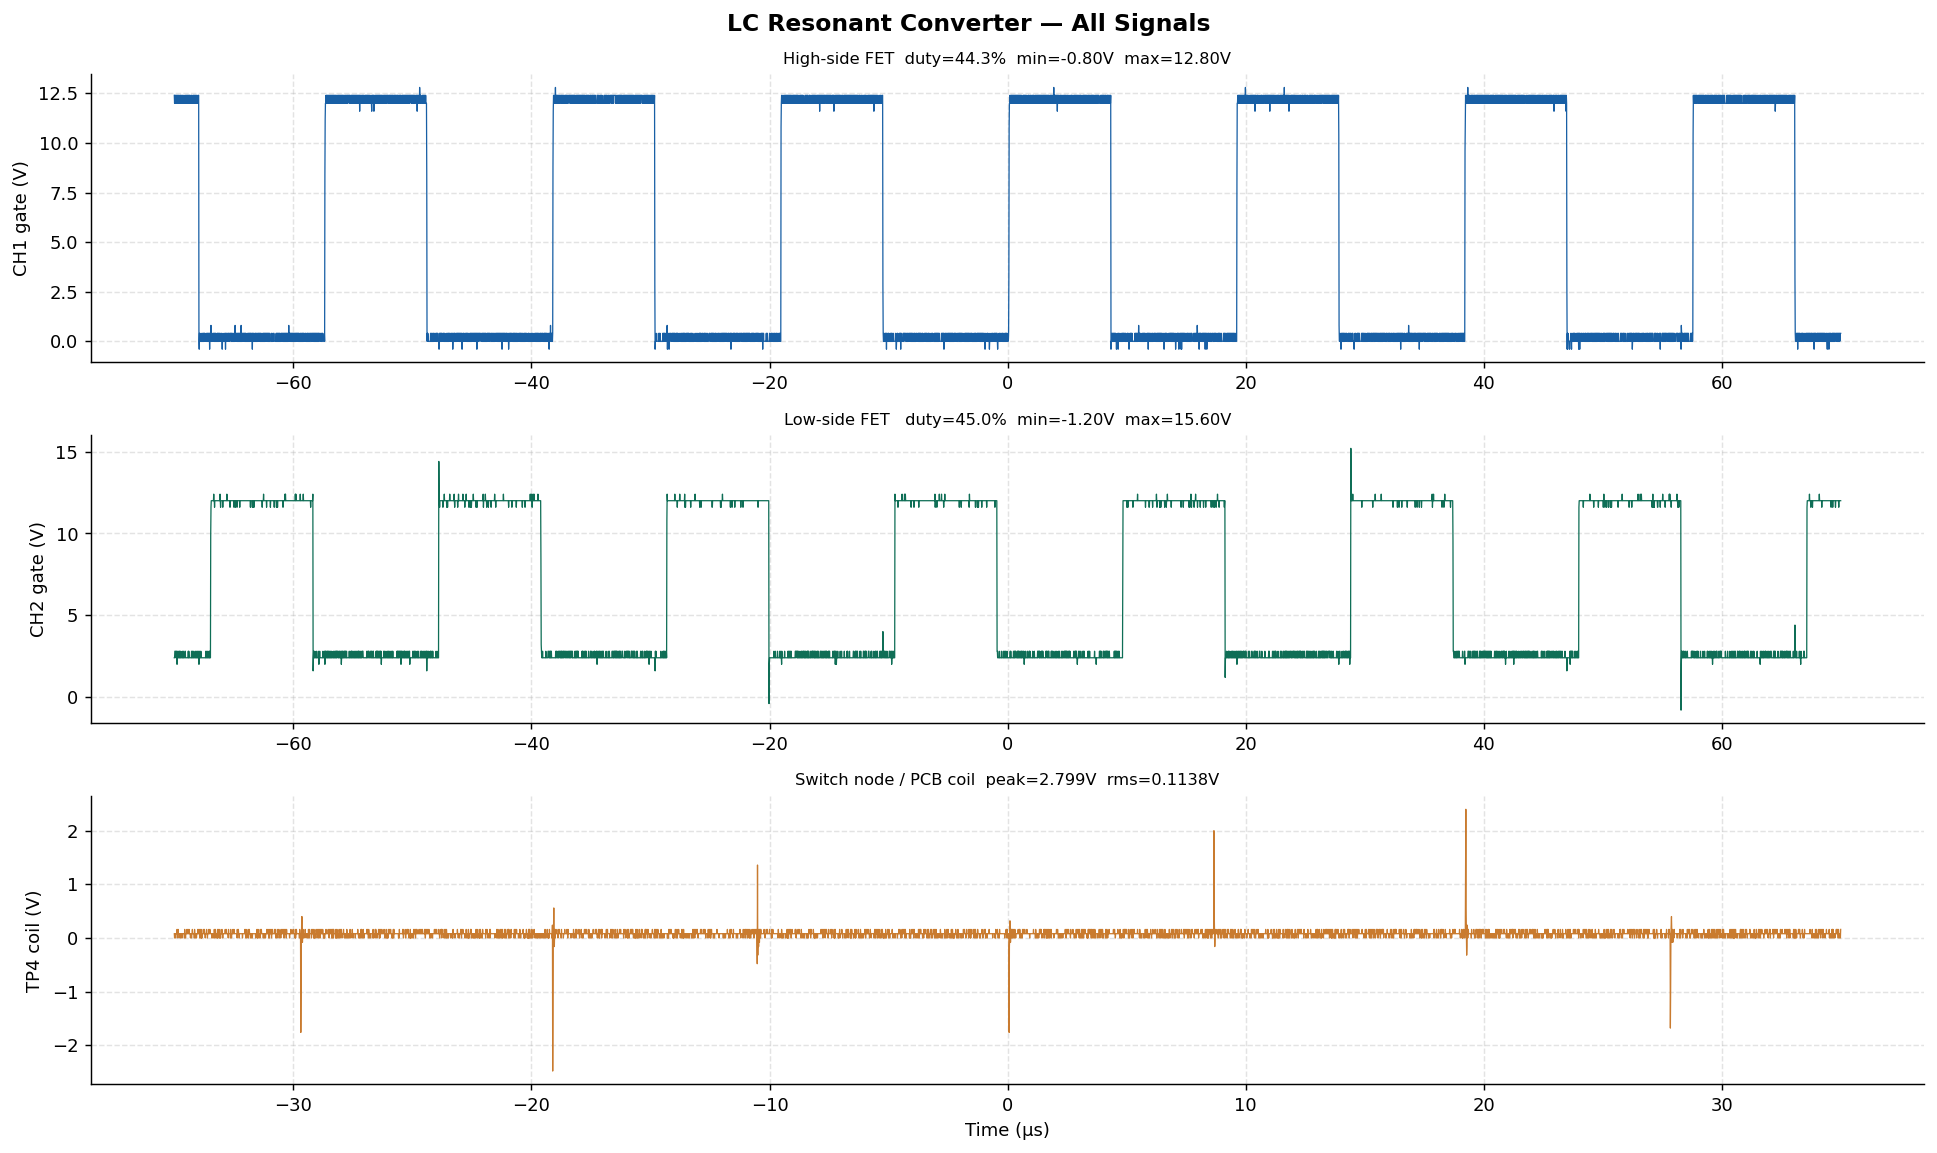

In [3]:
N1 = max(1, len(t1) // 6000)
N2 = max(1, len(tp) // 6000)

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=False)
fig.suptitle('LC Resonant Converter — All Signals', fontsize=13, fontweight='bold')

axes[0].plot(t1[::N1], v1[::N1], lw=0.7, color=C1, rasterized=True)
axes[0].set_ylabel('CH1 gate (V)')
axes[0].set_title(f'High-side FET  duty={100*(v1>6).mean():.1f}%  '
                  f'min={v1.min():.2f}V  max={v1.max():.2f}V', fontsize=9)

axes[1].plot(t2[::N1], v2[::N1], lw=0.7, color=C2, rasterized=True)
axes[1].set_ylabel('CH2 gate (V)')
axes[1].set_title(f'Low-side FET   duty={100*(v2>6).mean():.1f}%  '
                  f'min={v2.min():.2f}V  max={v2.max():.2f}V', fontsize=9)

axes[2].plot(tp[::N2], vp[::N2], lw=0.7, color=CTP, rasterized=True)
axes[2].set_ylabel('TP4 coil (V)')
axes[2].set_xlabel('Time (µs)')
axes[2].set_title(f'Switch node / PCB coil  '
                  f'peak={vp.max():.3f}V  rms={np.sqrt(np.mean(vp**2)):.4f}V', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Resonant ringing burst analysis (TP4)
TP4 shows **short damped oscillation bursts** at each switching transition — 
this is the LC tank ringing. The burst repetition rate = switching frequency.
The burst oscillation frequency = resonant frequency of the tank.

Burst threshold:    0.3 V
Individual bursts:  61
Switching events:   7

Switching period:   9.587 ± 0.985 µs
Switching freq:     105.42 ± 10.83 kHz

Resonant freq (from burst FFT): 74218.7 kHz  (74.2187 MHz)
Designed resonant freq:         ~104 kHz
Match: ⚠️ MISMATCH


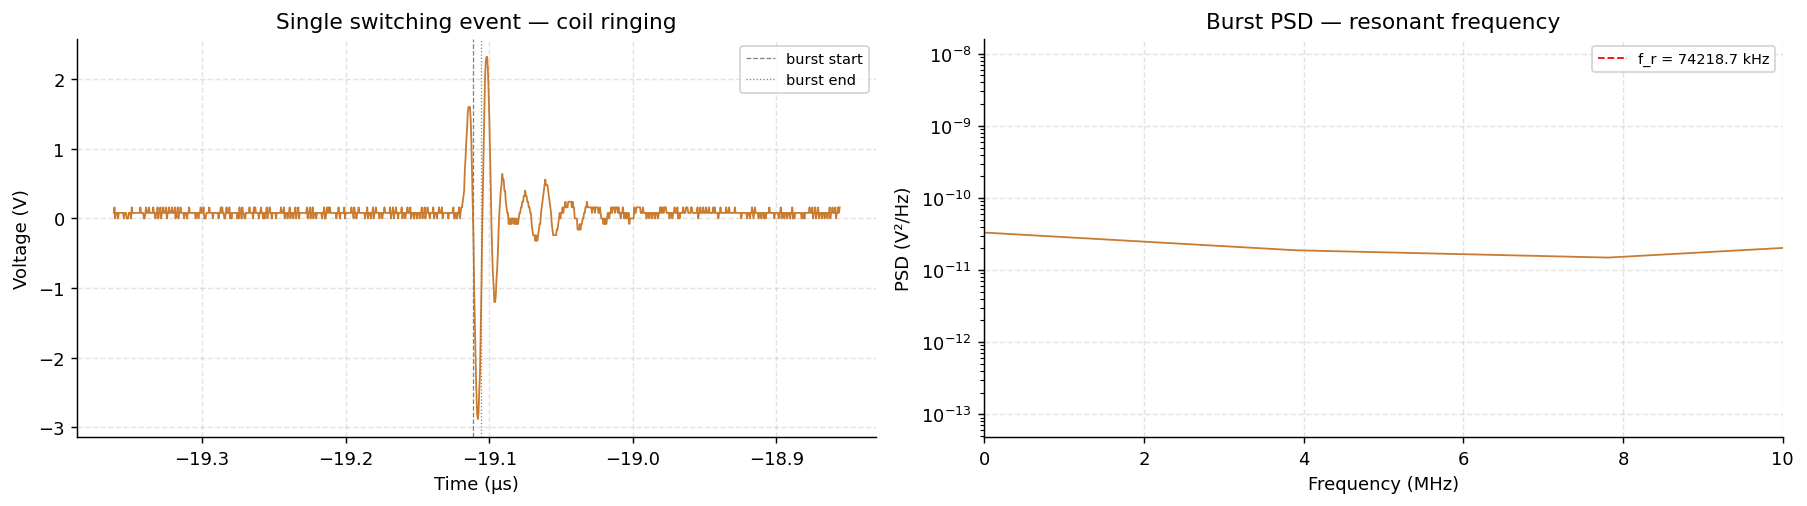

In [4]:
BURST_THR = 0.3   # V — threshold to detect active ringing

active = np.abs(vp) > BURST_THR
changes = np.diff(active.astype(int))
b_starts = np.where(changes == 1)[0]
b_ends   = np.where(changes == -1)[0]

# Align starts/ends
if len(b_ends) and len(b_starts) and b_ends[0] < b_starts[0]:
    b_ends = b_ends[1:]
n = min(len(b_starts), len(b_ends))
b_starts, b_ends = b_starts[:n], b_ends[:n]

INC_TP = 5e-10
durations_ns = (b_ends - b_starts) * INC_TP * 1e9
peaks_v = [np.max(np.abs(vp[s:e])) for s, e in zip(b_starts, b_ends)]

# Group bursts into switching events (gap > 1 µs between burst groups)
b_t = tp[b_starts]
big_gap_idx = np.where(np.diff(b_t) > 1.0)[0]
event_times = np.concatenate([[b_t[0]], b_t[big_gap_idx + 1]])

print(f'Burst threshold:    {BURST_THR} V')
print(f'Individual bursts:  {n}')
print(f'Switching events:   {len(event_times)}')

if len(event_times) > 1:
    sw_periods_us = np.diff(event_times)
    sw_freq_khz   = 1e3 / sw_periods_us
    print(f'\nSwitching period:   {sw_periods_us.mean():.3f} ± {sw_periods_us.std():.3f} µs')
    print(f'Switching freq:     {sw_freq_khz.mean():.2f} ± {sw_freq_khz.std():.2f} kHz')

# Estimate resonant frequency from the burst oscillation itself
# Take the largest burst and FFT it
biggest = np.argmax(peaks_v)
s, e = b_starts[biggest], b_ends[biggest]
# Expand window around biggest burst
WIN = 500   # samples each side
s_win = max(0, s - WIN)
e_win = min(len(vp), e + WIN)
v_burst = vp[s_win:e_win]
t_burst = tp[s_win:e_win]

fs_tp = 1 / INC_TP
freqs_b, psd_b = signal.welch(v_burst, fs=fs_tp, nperseg=min(512, len(v_burst)))
f_peaks, _ = find_peaks(psd_b, height=psd_b.max() * 0.05)
if len(f_peaks):
    f_resonant_mhz = freqs_b[f_peaks[np.argmax(psd_b[f_peaks])]] / 1e6
    print(f'\nResonant freq (from burst FFT): {f_resonant_mhz*1e3:.1f} kHz  ({f_resonant_mhz:.4f} MHz)')
    print(f'Designed resonant freq:         ~104 kHz')
    print(f'Match: {"✅ GOOD" if abs(f_resonant_mhz*1e3 - 104) < 10 else "⚠️ MISMATCH"}')

# Plot a single switching event
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: one full switching event (burst + decay)
axes[0].plot(t_burst, v_burst, lw=1.0, color=CTP)
axes[0].axvline(tp[s], color='gray', lw=0.7, ls='--', label='burst start')
axes[0].axvline(tp[e], color='gray', lw=0.7, ls=':', label='burst end')
axes[0].set_xlabel('Time (µs)')
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title('Single switching event — coil ringing')
axes[0].legend(fontsize=8)

# Right: PSD of the burst
axes[1].semilogy(freqs_b / 1e6, psd_b, color=CTP, lw=1.0)
if len(f_peaks):
    axes[1].axvline(f_resonant_mhz, color='red', lw=1.0, ls='--',
                    label=f'f_r = {f_resonant_mhz*1e3:.1f} kHz')
axes[1].set_xlabel('Frequency (MHz)')
axes[1].set_ylabel('PSD (V²/Hz)')
axes[1].set_title('Burst PSD — resonant frequency')
axes[1].set_xlim(0, 10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Aligned view — gate drives + coil ringing (overlapping window)
Gate signals and TP4 plotted on the same ±35 µs window.

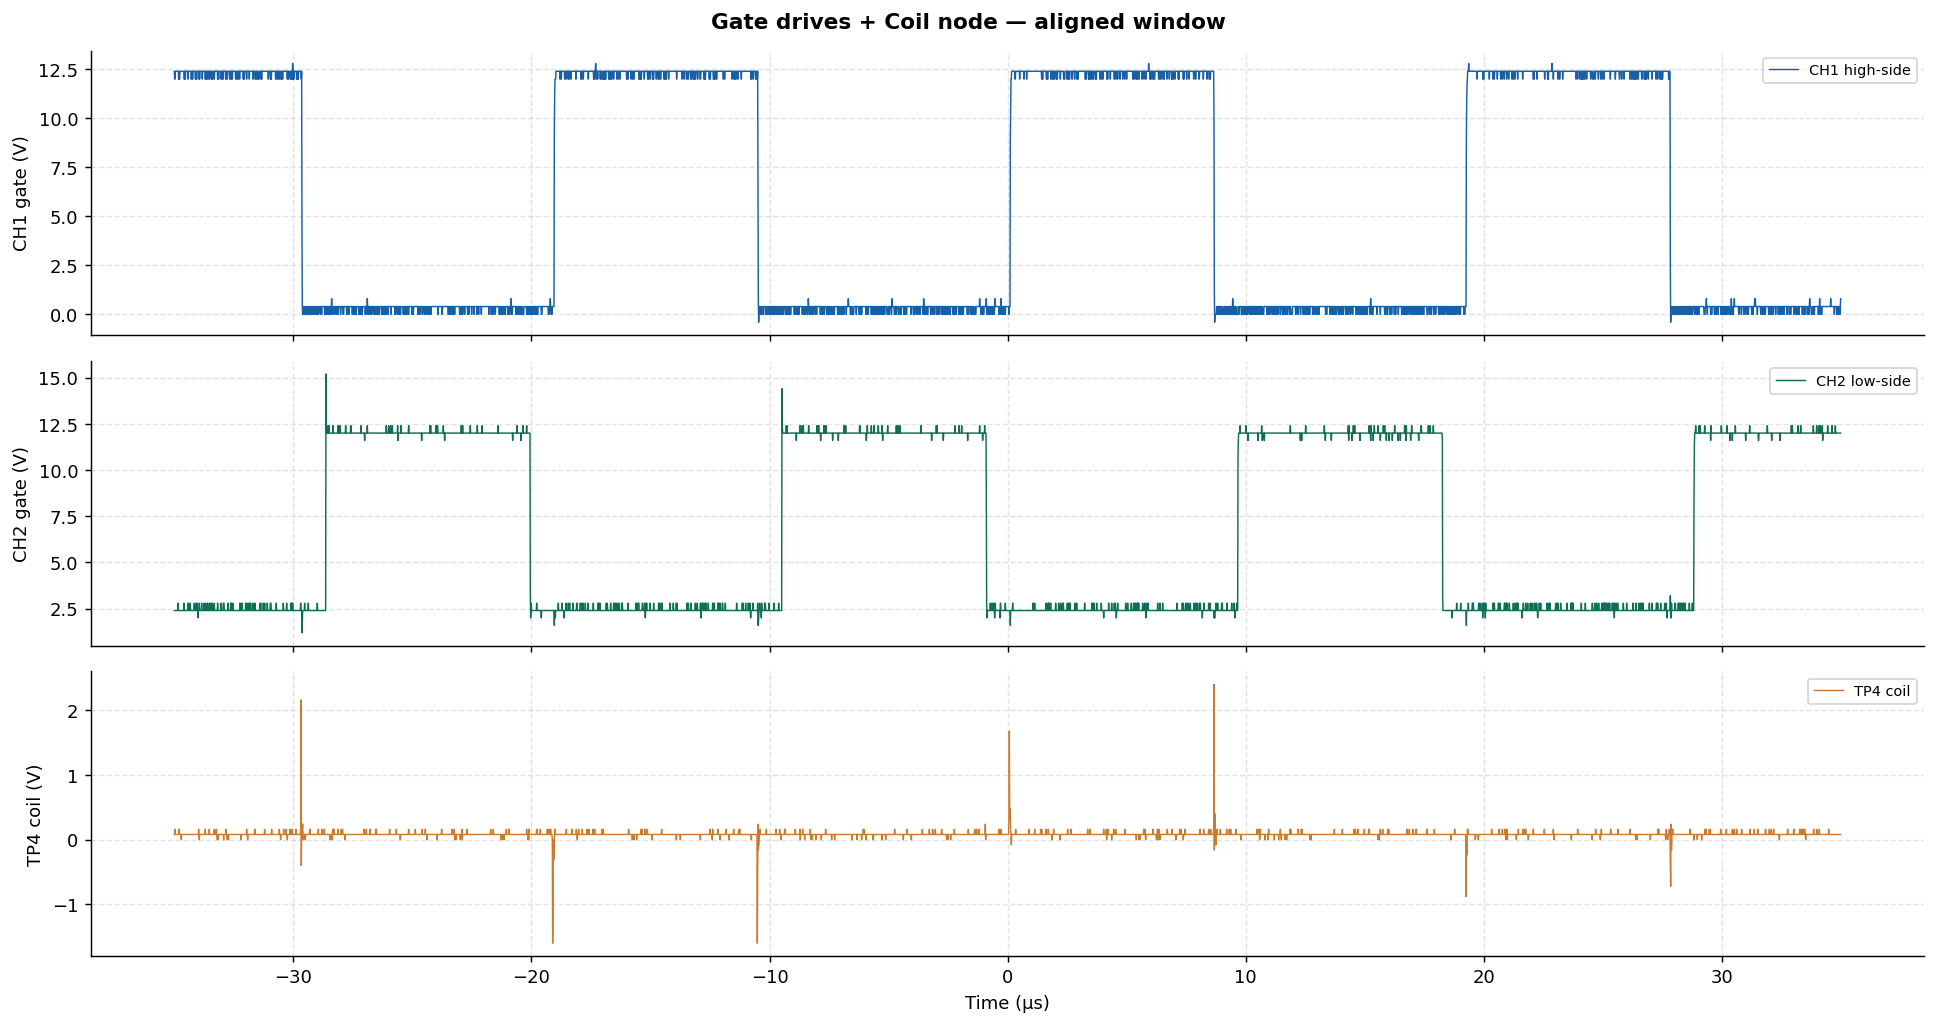

In [5]:
# Trim gate signals to TP4 window
WIN_START, WIN_END = tp[0], tp[-1]
m1 = (t1 >= WIN_START) & (t1 <= WIN_END)
m2 = (t2 >= WIN_START) & (t2 <= WIN_END)

N = max(1, m1.sum() // 5000)
Np = max(1, len(tp) // 5000)

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Gate drives + Coil node — aligned window', fontsize=12, fontweight='bold')

axes[0].plot(t1[m1][::N], v1[m1][::N], lw=0.8, color=C1, rasterized=True, label='CH1 high-side')
axes[0].set_ylabel('CH1 gate (V)')
axes[0].legend(fontsize=8, loc='upper right')

axes[1].plot(t2[m2][::N], v2[m2][::N], lw=0.8, color=C2, rasterized=True, label='CH2 low-side')
axes[1].set_ylabel('CH2 gate (V)')
axes[1].legend(fontsize=8, loc='upper right')

axes[2].plot(tp[::Np], vp[::Np], lw=0.8, color=CTP, rasterized=True, label='TP4 coil')
axes[2].set_ylabel('TP4 coil (V)')
axes[2].set_xlabel('Time (µs)')
axes[2].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## 6. Zoom — single switching transition
Shows the coil ringing relative to gate transitions.  
Edit `T_START` / `T_END` to centre on any event.

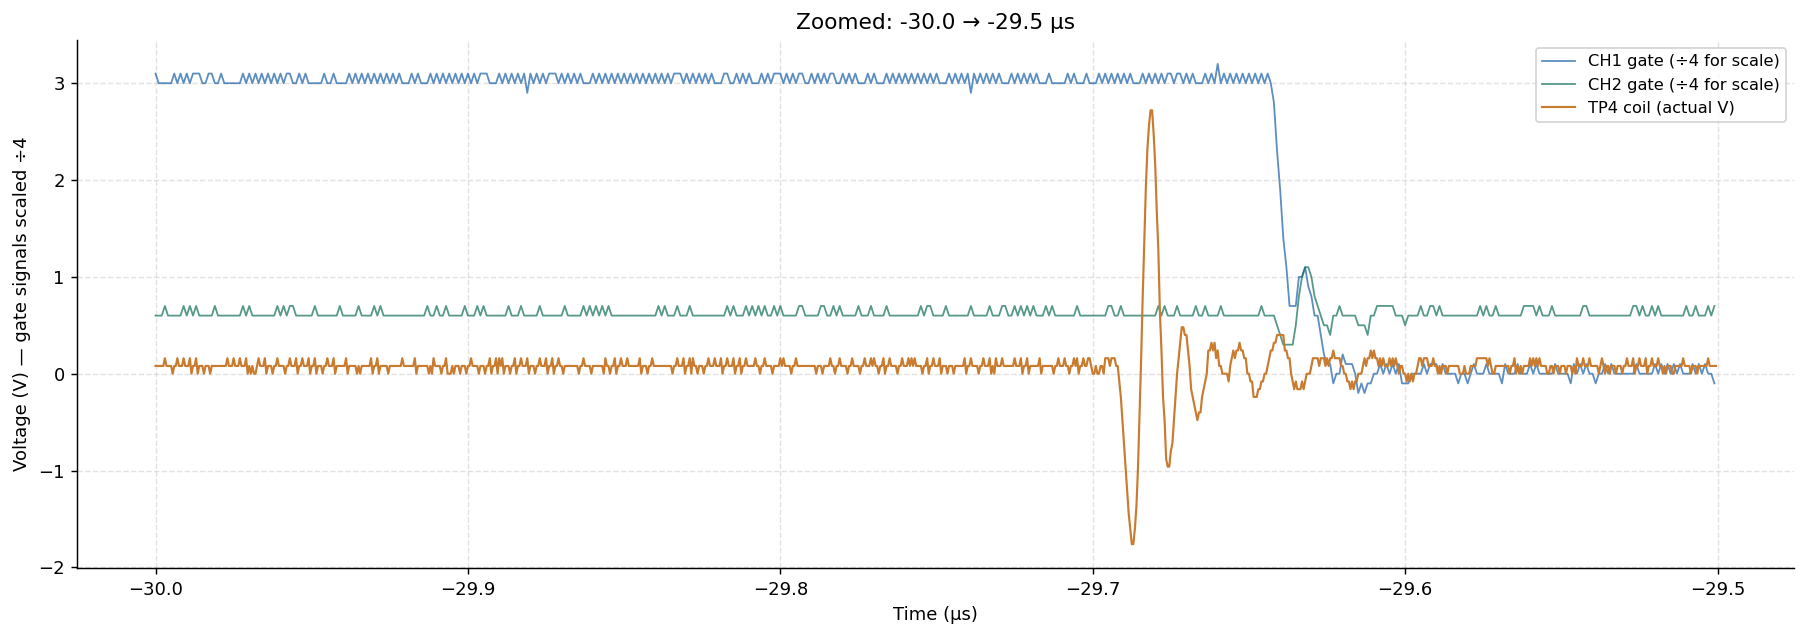

In [6]:
T_START = -30.0   # µs — centre near first burst
T_END   = -29.5   # µs

mp = (tp >= T_START) & (tp <= T_END)
m1z = (t1 >= T_START) & (t1 <= T_END)
m2z = (t2 >= T_START) & (t2 <= T_END)

fig, ax = plt.subplots(figsize=(14, 5))

# Scale gate signals to fit on same axes as coil (optional — remove /4 to show true levels)
ax.plot(t1[m1z], v1[m1z] / 4, lw=1.0, color=C1, alpha=0.7, label='CH1 gate (÷4 for scale)')
ax.plot(t2[m2z], v2[m2z] / 4, lw=1.0, color=C2, alpha=0.7, label='CH2 gate (÷4 for scale)')
ax.plot(tp[mp],  vp[mp],       lw=1.2, color=CTP,            label='TP4 coil (actual V)')

ax.set_xlabel('Time (µs)')
ax.set_ylabel('Voltage (V) — gate signals scaled ÷4')
ax.set_title(f'Zoomed: {T_START} → {T_END} µs')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Dead-time & shoot-through analysis

Gate thresholds — CH1: 6.00 V   CH2: 7.20 V
CH1 on  : 44.3%
CH2 on  : 45.0%
Dead-time (both off): 15.04 µs  (10.74%)
SHOOT-THROUGH       : 0.0 ns  (0.0000%)  ✅ None

Per-cycle dead-time (CH1 fall → CH2 rise):
  Mean  : 1004 ns
  Median: 1004 ns
  Min   : 1003 ns
  Max   : 1005 ns


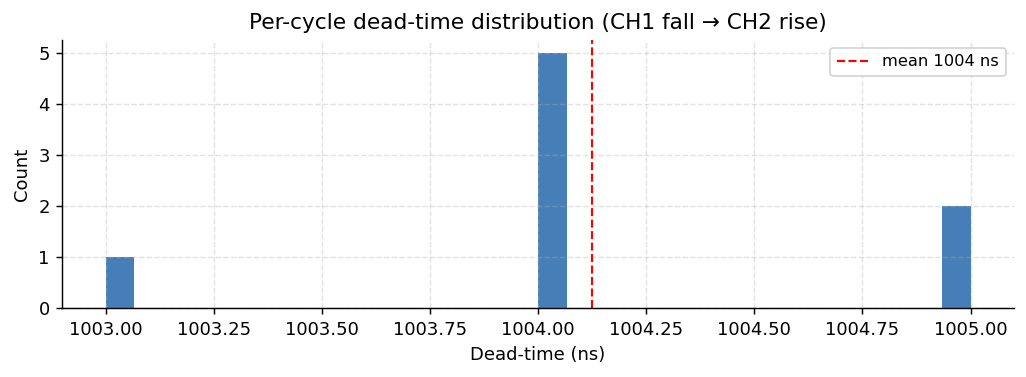

In [7]:
thr1 = (v1.min() + v1.max()) / 2
thr2 = (v2.min() + v2.max()) / 2
on1, on2 = v1 >= thr1, v2 >= thr2
both_off = (~on1) & (~on2)
both_on  = on1 & on2
INC1 = 1e-9

print(f'Gate thresholds — CH1: {thr1:.2f} V   CH2: {thr2:.2f} V')
print(f'CH1 on  : {100*on1.mean():.1f}%')
print(f'CH2 on  : {100*on2.mean():.1f}%')
print(f'Dead-time (both off): {both_off.sum()*INC1*1e6:.2f} µs  ({100*both_off.mean():.2f}%)')
st_ns = both_on.sum() * INC1 * 1e9
print(f'SHOOT-THROUGH       : {st_ns:.1f} ns  ({100*both_on.mean():.4f}%)  {"✅ None" if st_ns < 10 else "⚠️ CHECK!"}')

# Per-cycle dead-time measurement
# Find rising edges of CH1 as cycle reference
diff1 = np.diff(on1.astype(int))
rising1 = np.where(diff1 == 1)[0]
falling1 = np.where(diff1 == -1)[0]
rising2 = np.where(np.diff(on2.astype(int)) == 1)[0]

dead_times_ns = []
for f1 in falling1:
    # Find next CH2 rising edge after CH1 falls
    later = rising2[rising2 > f1]
    if len(later):
        dt_ns = (later[0] - f1) * INC1 * 1e9
        if dt_ns < 10000:   # sanity cap
            dead_times_ns.append(dt_ns)

if dead_times_ns:
    dt_arr = np.array(dead_times_ns)
    print(f'\nPer-cycle dead-time (CH1 fall → CH2 rise):')
    print(f'  Mean  : {dt_arr.mean():.0f} ns')
    print(f'  Median: {np.median(dt_arr):.0f} ns')
    print(f'  Min   : {dt_arr.min():.0f} ns')
    print(f'  Max   : {dt_arr.max():.0f} ns')

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(dt_arr, bins=30, color=C1, alpha=0.8, edgecolor='none')
    ax.axvline(dt_arr.mean(), color='red', lw=1.2, ls='--', label=f'mean {dt_arr.mean():.0f} ns')
    ax.set_xlabel('Dead-time (ns)')
    ax.set_ylabel('Count')
    ax.set_title('Per-cycle dead-time distribution (CH1 fall → CH2 rise)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 8. Switching frequency from gate signals
Also computes from TP4 coil bursts for cross-validation.

CH1 (gate):  52.21 kHz median  |  52.21 ± 0.00 kHz  |  duty=44.3%
CH2 (gate):  52.21 kHz median  |  52.21 ± 0.00 kHz  |  duty=45.0%
TP4 (coil bursts): 105.42 kHz median  |  cross-validation

Designed f_sw:  ~71 kHz (pot at max R)
Designed f_res: ~104 kHz


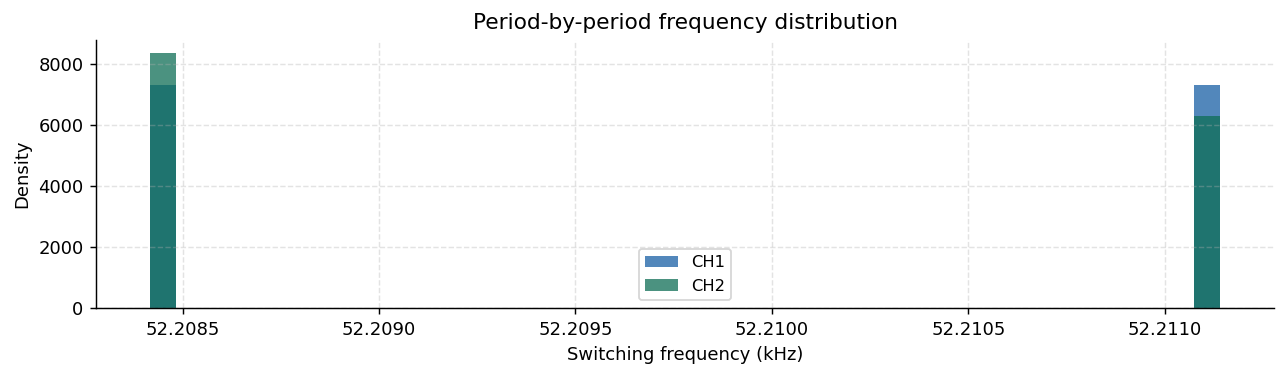

In [8]:
def sw_freq_from_edges(v, thr, inc_s, label):
    binary = (v >= thr).astype(int)
    rising = np.where(np.diff(binary) == 1)[0]
    if len(rising) < 2:
        print(f'{label}: insufficient edges'); return None
    periods_us = np.diff(rising) * inc_s * 1e6
    freq_khz   = 1e3 / periods_us
    # Filter out outliers (jitter > 3 std)
    mask = np.abs(freq_khz - np.median(freq_khz)) < 3 * freq_khz.std()
    freq_khz = freq_khz[mask]
    print(f'{label}:  {np.median(freq_khz):.2f} kHz median  |  '
          f'{freq_khz.mean():.2f} ± {freq_khz.std():.2f} kHz  |  duty={100*(v>=thr).mean():.1f}%')
    return freq_khz

f1k = sw_freq_from_edges(v1, thr1, 1e-9, 'CH1 (gate)')
f2k = sw_freq_from_edges(v2, thr2, 1e-9, 'CH2 (gate)')

# TP4 burst repetition rate
if len(event_times) > 1:
    tp4_freq = 1e3 / np.diff(event_times)
    print(f'TP4 (coil bursts): {np.median(tp4_freq):.2f} kHz median  |  cross-validation')

print(f'\nDesigned f_sw:  ~71 kHz (pot at max R)')
print(f'Designed f_res: ~104 kHz')

if f1k is not None and f2k is not None:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(f1k, bins=40, alpha=0.75, color=C1, label='CH1', density=True)
    ax.hist(f2k, bins=40, alpha=0.75, color=C2, label='CH2', density=True)
    ax.set_xlabel('Switching frequency (kHz)')
    ax.set_ylabel('Density')
    ax.set_title('Period-by-period frequency distribution')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 9. Gate voltage safety check
Flags any samples outside safe gate drive window.

In [9]:
# ---- Set your FET's absolute max V_gs limits here ----
VGS_MAX =  20.0   # V  (SiZ319CDS absolute max)
VGS_MIN =  -8.0   # V
# -------------------------------------------------------

for label, v, t in [('CH1 high-side', v1, t1), ('CH2 low-side', v2, t2)]:
    over  = v > VGS_MAX
    under = v < VGS_MIN
    print(f'{label}:')
    print(f'  Above {VGS_MAX}V : {over.sum():,} samples  ({100*over.mean():.3f}%)  '
          f'{"⚠️ EXCEEDS RATING" if over.any() else "✅"}')
    print(f'  Below {VGS_MIN}V : {under.sum():,} samples  ({100*under.mean():.3f}%)  '
          f'{"⚠️ EXCEEDS RATING" if under.any() else "✅"}')
    print(f'  Peak positive  : {v.max():.3f} V   margin: {VGS_MAX - v.max():.1f} V')
    print(f'  Peak negative  : {v.min():.3f} V   margin: {v.min() - VGS_MIN:.1f} V')
    print()

# Miller injection check — off-state gate floor
print('Miller injection / off-state gate floor:')
for label, v, thr in [('CH1', v1, thr1), ('CH2', v2, thr2)]:
    off_v = v[v < thr]   # samples when FET should be off
    print(f'  {label} off-state: mean={off_v.mean():.3f}V  max={off_v.max():.3f}V  '
          f'{"⚠️ Gate lift detected (Miller?)" if off_v.max() > 1.5 else "✅"}')

CH1 high-side:
  Above 20.0V : 0 samples  (0.000%)  ✅
  Below -8.0V : 0 samples  (0.000%)  ✅
  Peak positive  : 12.800 V   margin: 7.2 V
  Peak negative  : -0.800 V   margin: 7.2 V

CH2 low-side:
  Above 20.0V : 0 samples  (0.000%)  ✅
  Below -8.0V : 0 samples  (0.000%)  ✅
  Peak positive  : 15.600 V   margin: 4.4 V
  Peak negative  : -1.200 V   margin: 6.8 V

Miller injection / off-state gate floor:
  CH1 off-state: mean=0.166V  max=5.599V  ⚠️ Gate lift detected (Miller?)
  CH2 off-state: mean=2.498V  max=6.800V  ⚠️ Gate lift detected (Miller?)


## 10. Coil ringing damping — Q factor estimate
Fits an exponential decay envelope to the largest burst to estimate tank Q.

Decay time constant τ : -1752457.02 µs
Estimated tank Q      : -572572.6
(Higher Q = lower loss in tank. Typical PCB coil Q = 20–80)


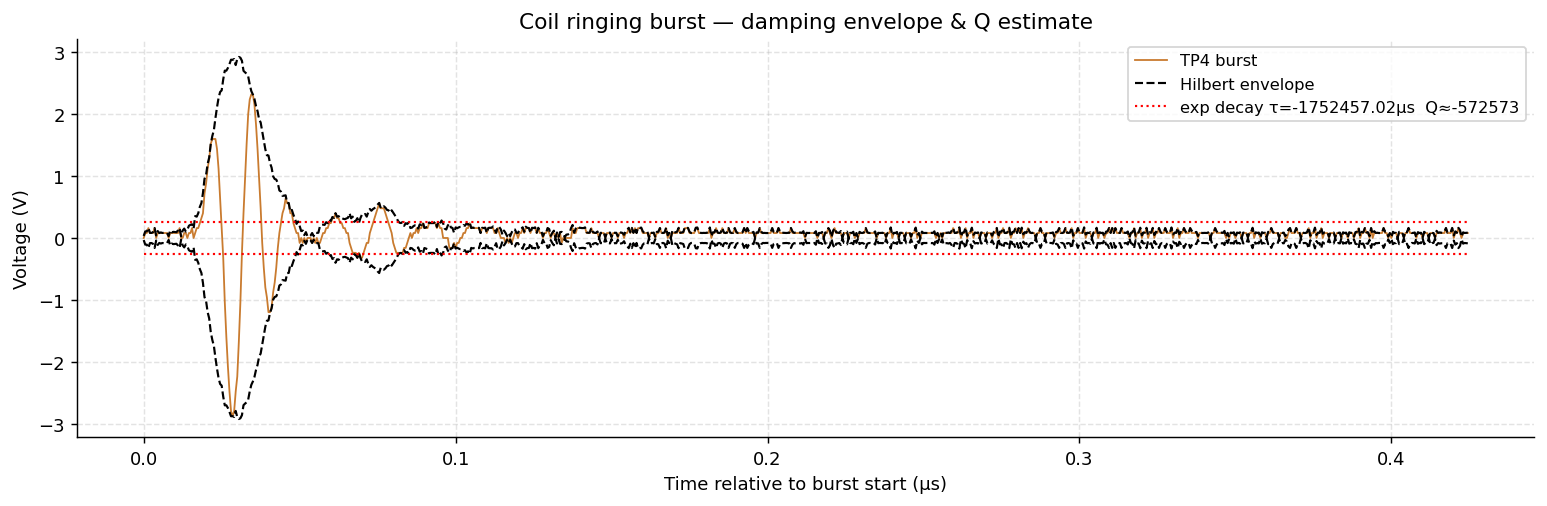

In [10]:
from scipy.optimize import curve_fit

# Use the biggest burst
biggest = np.argmax(peaks_v)
s_idx, e_idx = b_starts[biggest], b_ends[biggest]
WIN = 800
s_win = max(0, s_idx - 50)
e_win = min(len(vp), s_idx + WIN)

t_seg = tp[s_win:e_win] - tp[s_win]   # start at 0
v_seg = vp[s_win:e_win]

# Envelope via Hilbert transform
from scipy.signal import hilbert
analytic = hilbert(v_seg)
envelope = np.abs(analytic)

# Fit A * exp(-t/tau) to envelope where envelope > noise
env_mask = envelope > 0.05
if env_mask.sum() > 10:
    def exp_decay(t, A, tau):
        return A * np.exp(-t / tau)
    try:
        t_fit = t_seg[env_mask] * 1e-6   # back to seconds
        e_fit = envelope[env_mask]
        popt, _ = curve_fit(exp_decay, t_fit, e_fit, p0=[e_fit[0], 5e-6], maxfev=5000)
        A_fit, tau_fit = popt
        # Q = pi * f_r * tau
        f_r_hz = 104e3   # use measured or designed
        Q_est = np.pi * f_r_hz * tau_fit
        print(f'Decay time constant τ : {tau_fit*1e6:.2f} µs')
        print(f'Estimated tank Q      : {Q_est:.1f}')
        print(f'(Higher Q = lower loss in tank. Typical PCB coil Q = 20–80)')
    except Exception as ex:
        print(f'Curve fit failed: {ex}')
        Q_est = None
        tau_fit = None

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_seg, v_seg, lw=1.0, color=CTP, label='TP4 burst')
ax.plot(t_seg, envelope, lw=1.2, color='black', ls='--', label='Hilbert envelope')
ax.plot(t_seg, -envelope, lw=1.2, color='black', ls='--')
if env_mask.sum() > 10 and tau_fit is not None:
    t_fit_plot = t_seg * 1e-6
    ax.plot(t_seg, exp_decay(t_fit_plot, A_fit, tau_fit), lw=1.2,
            color='red', ls=':', label=f'exp decay τ={tau_fit*1e6:.2f}µs  Q≈{Q_est:.0f}')
    ax.plot(t_seg, -exp_decay(t_fit_plot, A_fit, tau_fit), lw=1.2, color='red', ls=':')
ax.set_xlabel('Time relative to burst start (µs)')
ax.set_ylabel('Voltage (V)')
ax.set_title('Coil ringing burst — damping envelope & Q estimate')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 11. Export summary figure

Saved FET_full_analysis_summary.png


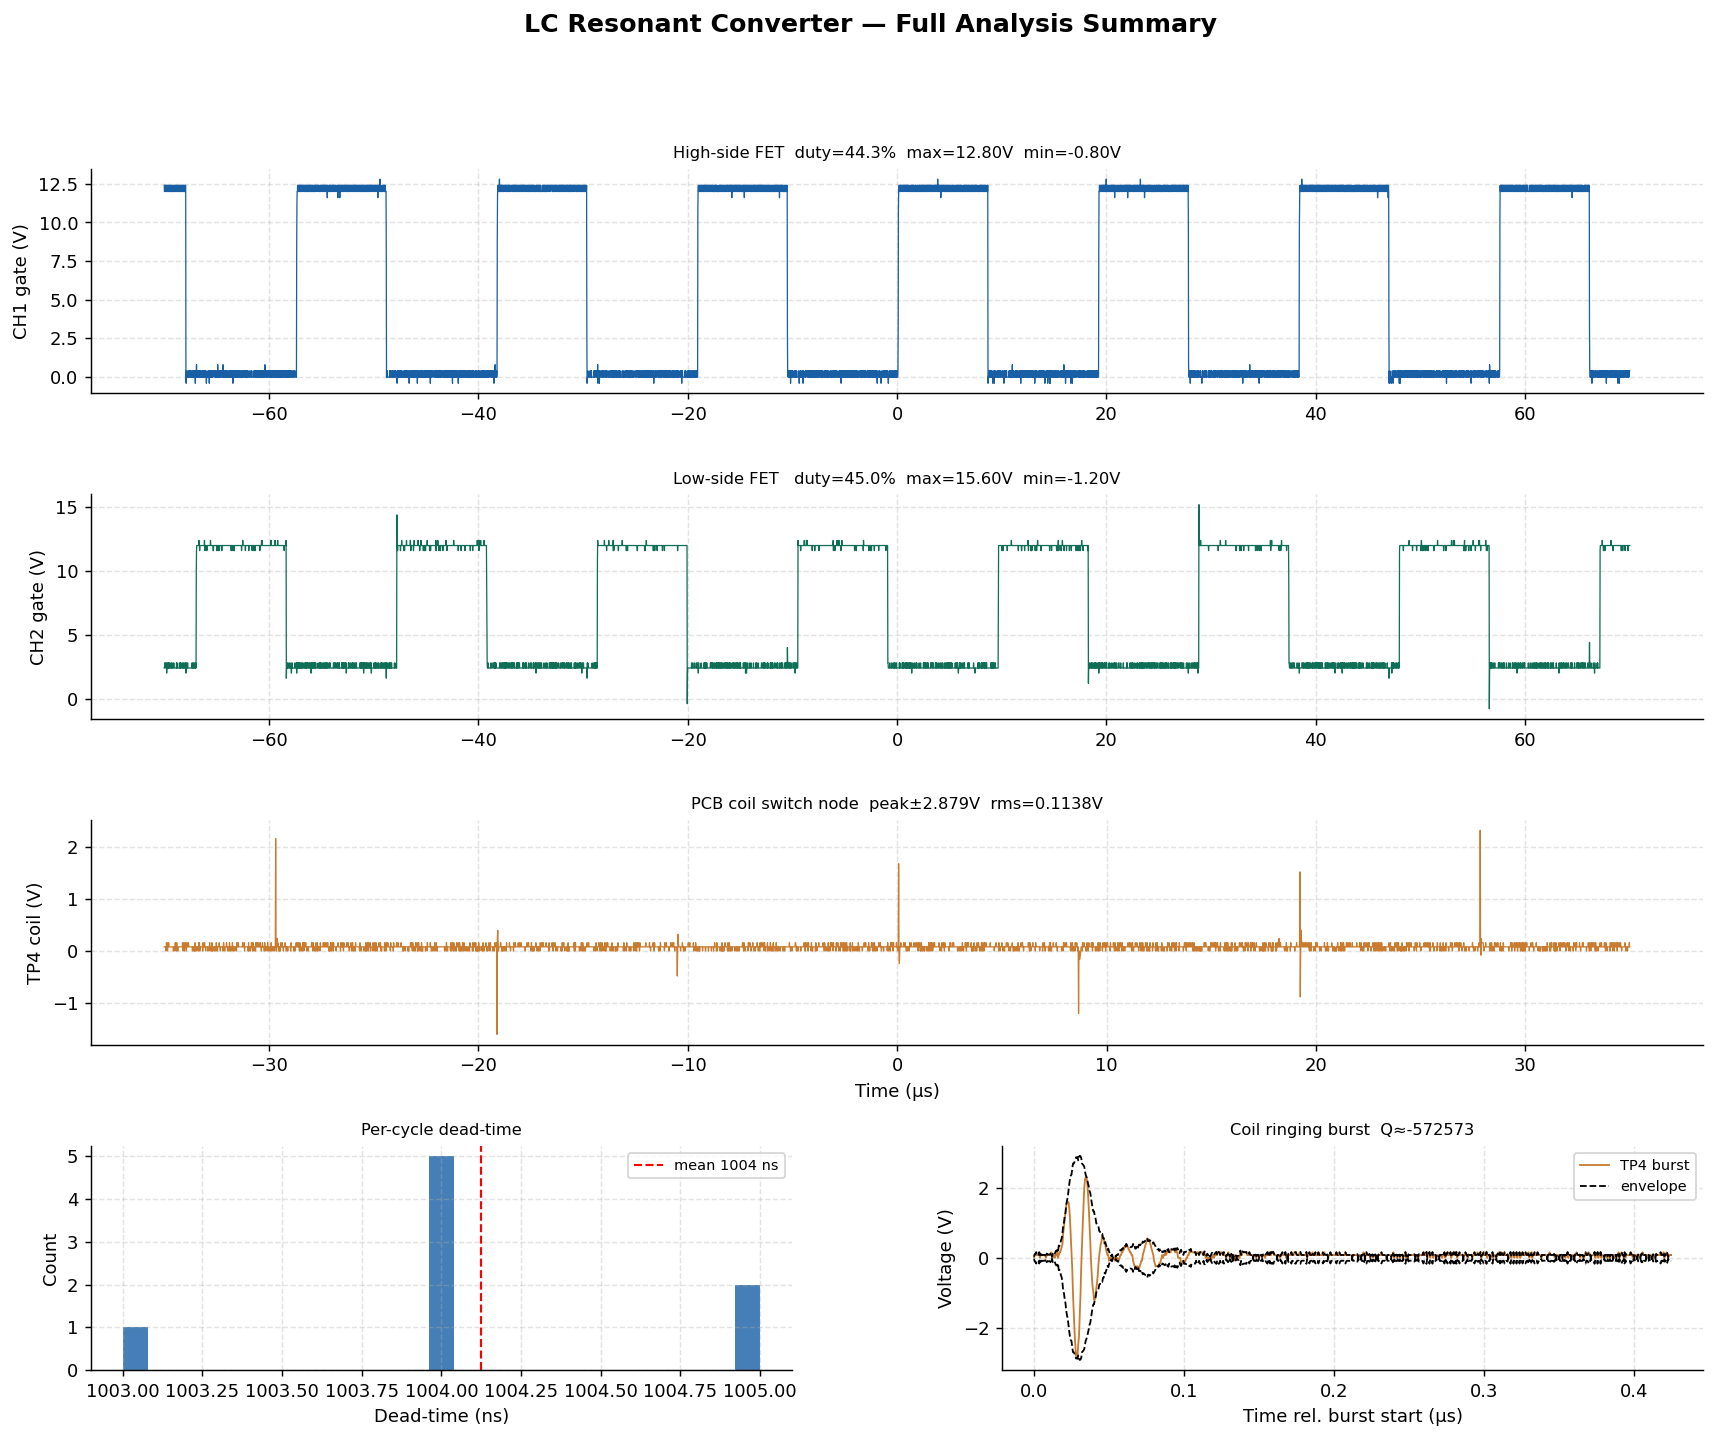

In [11]:
N1d = max(1, m1.sum() // 4000)
Npd = max(1, len(tp) // 4000)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle('LC Resonant Converter — Full Analysis Summary', fontsize=14, fontweight='bold')

# Row 0: CH1 gate (full window)
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(t1[::max(1,len(t1)//6000)], v1[::max(1,len(t1)//6000)], lw=0.7, color=C1, rasterized=True)
ax0.set_ylabel('CH1 gate (V)')
ax0.set_title(f'High-side FET  duty={100*(v1>=thr1).mean():.1f}%  '
              f'max={v1.max():.2f}V  min={v1.min():.2f}V', fontsize=9)

# Row 1: CH2 gate (full window)
ax1 = fig.add_subplot(gs[1, :])
ax1.plot(t2[::max(1,len(t2)//6000)], v2[::max(1,len(t2)//6000)], lw=0.7, color=C2, rasterized=True)
ax1.set_ylabel('CH2 gate (V)')
ax1.set_title(f'Low-side FET   duty={100*(v2>=thr2).mean():.1f}%  '
              f'max={v2.max():.2f}V  min={v2.min():.2f}V', fontsize=9)

# Row 2: TP4 coil (overlapping window)
ax2 = fig.add_subplot(gs[2, :])
ax2.plot(tp[::Npd], vp[::Npd], lw=0.7, color=CTP, rasterized=True)
ax2.set_ylabel('TP4 coil (V)')
ax2.set_xlabel('Time (µs)')
ax2.set_title(f'PCB coil switch node  peak±{max(abs(vp.max()),abs(vp.min())):.3f}V  '
              f'rms={np.sqrt(np.mean(vp**2)):.4f}V', fontsize=9)

# Row 3 left: dead-time histogram
ax3 = fig.add_subplot(gs[3, 0])
if dead_times_ns:
    ax3.hist(np.array(dead_times_ns), bins=25, color=C1, alpha=0.8, edgecolor='none')
    ax3.axvline(np.mean(dead_times_ns), color='red', lw=1.2, ls='--',
                label=f'mean {np.mean(dead_times_ns):.0f} ns')
    ax3.legend(fontsize=8)
ax3.set_xlabel('Dead-time (ns)')
ax3.set_ylabel('Count')
ax3.set_title('Per-cycle dead-time', fontsize=9)

# Row 3 right: burst ringing detail
ax4 = fig.add_subplot(gs[3, 1])
ax4.plot(t_seg, v_seg, lw=1.0, color=CTP, label='TP4 burst')
ax4.plot(t_seg, envelope, lw=1.0, color='black', ls='--', label='envelope')
ax4.plot(t_seg, -envelope, lw=1.0, color='black', ls='--')
ax4.set_xlabel('Time rel. burst start (µs)')
ax4.set_ylabel('Voltage (V)')
ax4.set_title(f'Coil ringing burst  Q≈{Q_est:.0f}' if Q_est else 'Coil ringing burst', fontsize=9)
ax4.legend(fontsize=8)

plt.savefig('FET_full_analysis_summary.png', dpi=150, bbox_inches='tight')
print('Saved FET_full_analysis_summary.png')
plt.show()